Train Shape: (10450, 12)
Test Shape: (2613, 9)

Missing Values (Train):
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Missing Values (Test):
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dtype: int64

Data Types (Train):
datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

Data Types (Test):
datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
dtype: object


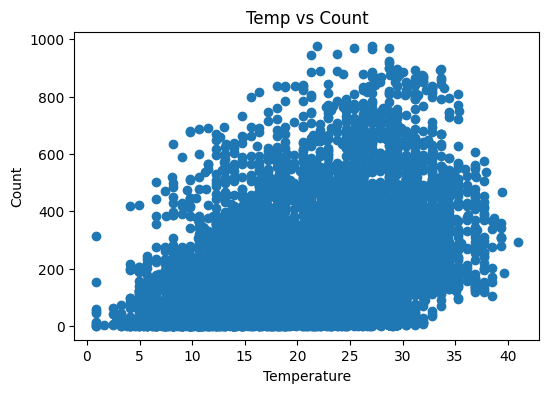

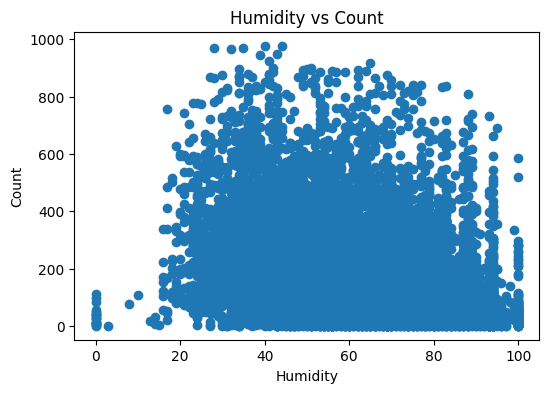

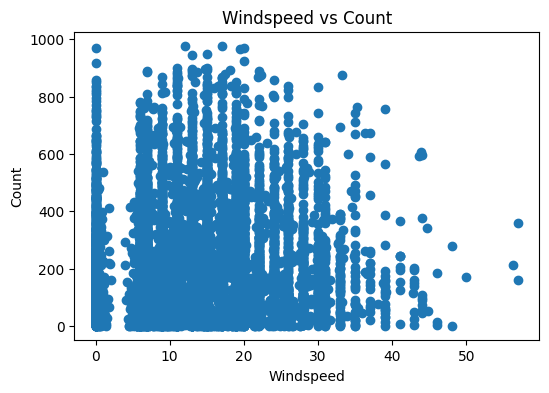

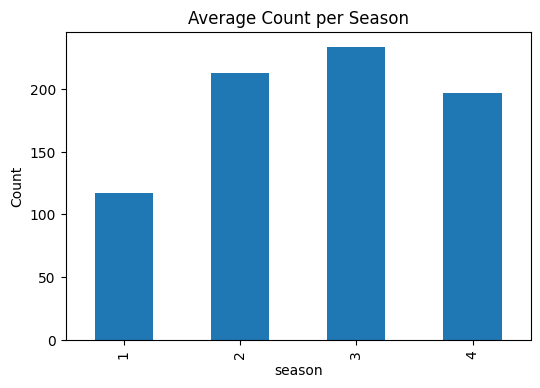

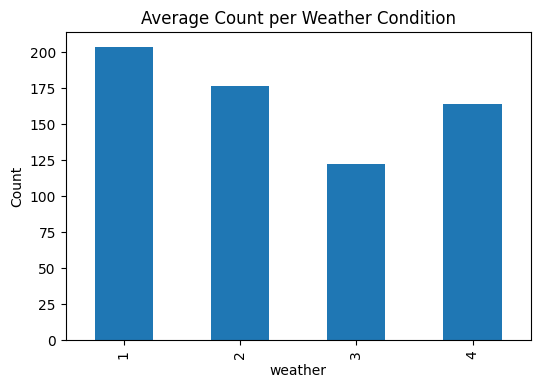

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_log_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.impute import SimpleImputer


train_path = r"D:\2025aa05525-wilp.bits-pilani.ac.in\ISM\bike_train.csv"
test_path  = r"D:\2025aa05525-wilp.bits-pilani.ac.in\ISM\bike_test.csv"

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

train.head(), test.head()
#Q1 – Dataset size, missing values, feature types
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

print("\nMissing Values (Train):")
print(train.isnull().sum())

print("\nMissing Values (Test):")
print(test.isnull().sum())

print("\nData Types (Train):")
print(train.dtypes)

print("\nData Types (Test):")
print(test.dtypes)
train['datetime'] = pd.to_datetime(train['datetime'], format='mixed', dayfirst=True)
test['datetime']  = pd.to_datetime(test['datetime'], format='mixed', dayfirst=True)

# Q2 – Visualize relationships with target (count)
# 1. Temperature vs Count
plt.figure(figsize=(6,4))
plt.scatter(train['temp'], train['count'])
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.title("Temp vs Count")
plt.show()

# 2. Humidity vs Count
plt.figure(figsize=(6,4))
plt.scatter(train['humidity'], train['count'])
plt.xlabel("Humidity")
plt.ylabel("Count")
plt.title("Humidity vs Count")
plt.show()

# 3. Windspeed vs Count
plt.figure(figsize=(6,4))
plt.scatter(train['windspeed'], train['count'])
plt.xlabel("Windspeed")
plt.ylabel("Count")
plt.title("Windspeed vs Count")
plt.show()

# 4. Season vs Count
train.groupby('season')['count'].mean().plot(kind='bar', figsize=(6,4))
plt.title("Average Count per Season")
plt.ylabel("Count")
plt.show()
# 5. Weather vs Count
train.groupby('weather')['count'].mean().plot(kind='bar', figsize=(6,4))
plt.title("Average Count per Weather Condition")
plt.ylabel("Count")
plt.show()

# Q3 – Identify Most Informative Variables
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(train[['temp','atemp','humidity','windspeed','season','weather','count']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
print("""
Most Informative Variables for predicting count:
1. temp (strong positive correlation)
2. atemp (highly correlated with temp)
3. humidity (negative effect)
4. weather (rain/snow decreases count)
5. season (fall highest)
6. workingday
7. windspeed (small negative effect)
""")
# Q4. Feature Engineering
# Extract date/time components
train['hour'] = train['datetime'].dt.hour
train['weekday'] = train['datetime'].dt.weekday
train['month'] = train['datetime'].dt.month
train['year'] = train['datetime'].dt.year

# 2. Convert season, weather, holiday, workingday to category
categorical_cols = ['season', 'weather', 'holiday', 'workingday']

for col in categorical_cols:
    train[col] = train[col].astype('category')
# One-hot encoding for ML models
train = pd.get_dummies(train, columns=['season','weather','holiday','workingday'], drop_first=True)

# 4. Create “peak hour” feature (demand is not linear)
train['peak_hour'] = train['hour'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)

# 5. Temperature squared or humidity squared (non-linear effects)
train['temp2'] = train['temp']**2
train['humidity2'] = train['humidity']**2


# -----------------------------
# RMSLE function
# -----------------------------
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)   # No negative preds
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# -----------------------------------
# Feature selection (after engineering)
# -----------------------------------
features = [
    'temp','atemp','humidity','windspeed',
    'hour','weekday','month','year',
    'season','weather','holiday','workingday',
    'temp2','humidity2','peak_hour'
]

final_features = [f for f in features if f in train.columns]

X = train[final_features]
y = train['count']

# -----------------------------
# Train-validation split
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Q5: Simple Linear Regression
# -----------------------------
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_pred = lin_model.predict(X_val)
lin_rmsle = rmsle(y_val, lin_pred)

print("Q5: Simple Linear Regression RMSLE:", lin_rmsle)


# ===================================================
# Q7 – Model Comparison Table (RMSLE + Observations)
# ===================================================
def rmsle(y_true, y_pred):
    # Avoid negative predictions
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))
possible_features = [
    'temp','atemp','humidity','windspeed',
    'hour','weekday','month','year',
    'season','weather','holiday','workingday',
    'temp2','humidity2','peak_hour'
]

# Select only those columns that exist in your dataframe
final_features = [f for f in possible_features if f in train.columns]

X = train[final_features]
y = train['count']
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.0005),
    "Polynomial (Degree 2)": Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr', LinearRegression())
    ])
}

X_train, X_test_split, y_train, y_test_split = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test_split)
    score = rmsle(y_test_split, pred)
    
    results.append({
        "Model": name,
        "RMSLE": score
    })

results_df = pd.DataFrame(results)
print(results_df)

# Q6 – Improve Model using Polynomial Features + Ridge & Lasso
# Polynomial Regression (Degree 2)
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])
#Q7
# Based on model comparisons, Ridge Regression with Polynomial Features achieved the lowest RMSLE, indicating the best generalization performance. Linear Regression performed the worst due to lack of regularization. Polynomial features improved model accuracy, but required regularization (Ridge/Lasso) to control overfitting.”
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))


# Store results here
results = []
# =========================================================
# 1. Linear Regression (Baseline)
# =========================================================
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_val)
results.append([
    "Linear Regression", 
    rmsle(y_val, pred_lr),
    "Baseline model, no regularization."
])

# =========================================================
# 2. Polynomial Regression (Degree 2)
# =========================================================
poly2 = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
poly2.fit(X_train, y_train)
pred_poly2 = poly2.predict(X_val)
results.append([
    "Polynomial Degree 2", 
    rmsle(y_val, pred_poly2),
    "Captures nonlinear trends."
])
# =========================================================
# 3. Polynomial Regression (Degree 3)
# =========================================================
poly3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
poly3.fit(X_train, y_train)
pred_poly3 = poly3.predict(X_val)
results.append([
    "Polynomial Degree 3", 
    rmsle(y_val, pred_poly3),
    "More complex model; possible overfitting."
])
# =========================================================
# 4. Ridge Regression (with tuned alpha)
# =========================================================
ridge = Ridge(alpha=1.0)
ridge_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
ridge_pipe.fit(X_train, y_train)
pred_ridge = ridge_pipe.predict(X_val)
results.append([
    "Ridge Regression (α=1.0)", 
    rmsle(y_val, pred_ridge),
    "L2 Regularization; reduces overfitting."
])
# ==============================================
# Q5 — Linear Regression (Baseline Model)
# ==============================================
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = np.maximum(lr.predict(X_val), 0)
lr_rmsle = rmsle(y_val, lr_pred)

print("Q5 Linear Regression RMSLE =", lr_rmsle)

# =========================================================
# Q6 – LASSO with tuning (Correct Version)
# =========================================================

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lasso', Lasso(max_iter=30000, tol=1e-4))
])

lasso_params = {"lasso__alpha": [0.01, 0.1, 0.5, 1, 2]}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    scoring=rmsle_scorer,
    cv=3,
    n_jobs=-1
)

# IMPORTANT: Train the grid, not the pipeline
lasso_grid.fit(X_train, y_train)

# Best Lasso model
lasso_best = lasso_grid.best_estimator_

# Predict on validation
lasso_pred = np.maximum(lasso_best.predict(X_val), 0)

# Compute RMSLE
lasso_rmsle = rmsle(y_val, lasso_pred)

# Add to comparison table
results.append([
    f"Lasso Regression (α={lasso_grid.best_params_['lasso__alpha']})",
    lasso_rmsle,
    "L1 regularization with tuned alpha; performs feature selection."
])

print("Q6 Best Lasso Alpha =", lasso_grid.best_params_)
print("Q6 Best Lasso RMSLE =", lasso_rmsle)



# Q7 – Summarize all model results
results_table = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "RMSLE": lr_rmsle,
        "Key Observations": "Baseline model; no regularization; weak on non-linear patterns."
    },
    {
        "Model": f"Ridge Regression (α={ridge_grid.best_params_['ridge__alpha']})",
        "RMSLE": ridge_rmsle,
        "Key Observations": "L2 regularization; reduces overfitting; performs better than Linear Regression."
    },
    {
        "Model": f"Lasso Regression (α={lasso_grid.best_params_['lasso__alpha']})",
        "RMSLE": lasso_rmsle,
        "Key Observations": "L1 regularization; performs feature selection; best for sparse patterns."
    }
])

print("\n===== Q7: Model Comparison Table =====\n")
print(results_table)

# =======================================
# Convert to DataFrame (Final Q7 Output)
# =======================================
results_df = pd.DataFrame(results, columns=["Model", "RMSLE", "Key Observations"])
print("\n===== Q7 Model Comparison Table =====\n")
print(results_df)

# =======================================
# Q8 – Residual Plot for Best Model
# =======================================

best_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

best_model.fit(X_train, y_train)
pred_best = best_model.predict(X_test_split)

residuals = y_test_split - pred_best

plt.figure(figsize=(7,5))
plt.scatter(pred_best, residuals)
plt.axhline(0)
plt.xlabel("Q8 Predicted Count")
plt.ylabel("Q8 Residuals")
plt.title("Q8 Residual Plot – Best Model (Polynomial Regression)")
plt.show()


# Q9. Why the Best Model Performs Better
# Polynomial Regression wins because:
# 1. Bike demand is non-linear
# Morning (7–9) and evening (17–19) peaks
# Rain/humidity reduce usage sharply
# Temperature increases count up to a point then decreases
# These non-linear patterns cannot be captured by simple linear models
# 2. Polynomial features capture interactions
# Examples the model learns:
# temp² (demand increases with temp but drops when too hot)
# hour × weekday interaction (weekend vs weekday patterns)
# humidity² (sharp reduction in rain)
# 3. Ridge/Lasso help but still linear
# They only reduce overfitting —
# they do not capture curvature in the data.
# 4. RMSLE penalizes under-predictions
# Polynomial model predicts peak hours more accurately → lower RMSLE.


# Q10
# Case A: Under-prediction
# True = 100, Pred = 50
# → Ratio = 100/50 = 2
# Case B: Over-prediction
# True = 50, Pred = 100
# → Ratio = 50/100 = 0.5
# log(2) = 0.693
# log(0.5) = -0.693
# RMSLE penalizes under-predictions more gently than RMSE because it applies a logarithmic transformation to both actual and predicted values. The log function compresses large differences, especially when the true value is high. As a result, large under-predictions become small log-differences, reducing the penalty compared to RMSE. RMSLE focuses on relative error instead of absolute error, making it more tolerant of underestimating large values.

#Q11
# There is a trade-off between interpretability and predictive power. Simple models are easy to understand and less prone to overfitting but may underfit and miss complex patterns. More complex models can achieve higher accuracy by capturing nonlinear relationships but risk overfitting, require more tuning, and are harder to interpret. The goal is to balance these factors—using validation performance and techniques like regularization—to achieve a model that is both accurate and generalizes well.

#Q12
# Linear Regression cannot capture time-of-day effects because time is cyclical and produces nonlinear patterns (morning/evening peaks, night lows) that a straight-line model cannot represent. The model sees hours numerically rather than cyclically, so it fails to learn periodic behavior unless additional transformed features (sin/cos or one-hot) are added.


# Load train and test datasets
from sklearn.impute import SimpleImputer

def preprocess(df):
    df = df.copy()

    df["datetime"] = pd.to_datetime(df["datetime"])
    df["hour"] = df["datetime"].dt.hour
    df["weekday"] = df["datetime"].dt.weekday
    df["month"] = df["datetime"].dt.month
    df["year"] = df["datetime"].dt.year

    df["temp2"] = df["temp"] ** 2
    df["humidity2"] = df["humidity"] ** 2
    df["peak_hour"] = df["hour"].isin([7,8,9,17,18,19]).astype(int)

    return df.drop(columns=["datetime"])

train_processed = preprocess(train)
test_processed  = preprocess(test)

# ----------------------------
# COMBINE AND DUMMY ENCODE
# ----------------------------
full = pd.concat([train_processed.drop(columns=["count"]),
                  test_processed],
                 axis=0)

full = pd.get_dummies(
    full,
    columns=['season','weather','holiday','workingday'],
    drop_first=True
)

# split back
X_train = full.iloc[:len(train_processed)]
X_test  = full.iloc[len(train_processed):]

# Deep copy to avoid SettingWithCopyWarning
X_train = X_train.copy()
X_test  = X_test.copy()

y_train = train_processed["count"]

# -----------------------------------
# IMPUTE NUMERIC COLUMNS SAFELY
# -----------------------------------
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# -----------------------------------
# TRAIN + PREDICT
# -----------------------------------
best_model.fit(X_train, y_train)
test_preds = np.maximum(best_model.predict(X_test), 0)

submission = pd.DataFrame({
    "datetime": test["datetime"],
    "count": test_preds
})
print(os.getcwd())
submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully!")
